# CV Screener — демо и разбор

Ноутбук проводит пакет `cv_screener` по всему пути: персоны → профили → PDF → индекс → поиск → агент → эвалы.
Каждая ячейка вызывает те же функции, что и CLI. То, что видно ниже, ровно то,
что делают `cv generate`, `cv index`, `cv search` и `cv chat`.


```mermaid
flowchart LR
    P[personas.py<br/>14 спецификаций] --> G[LLM через OpenRouter<br/>JSON по Pydantic-схеме]
    G --> J[(data/candidates/*.json)]
    J --> R[Jinja2 + WeasyPrint<br/>3 макета × темы]
    R --> PDF[(data/pdf/*.pdf)]
    J --> I[ChromaDB<br/>вектор + метаданные]
    I --> S[search / get / find_by_name]
    S --> A[Агент: цикл тулов]
    A --> CLI[cv chat]
    S --> E[Эвалы]
```

Одна сущность `Candidate` (Pydantic-модель в `schema.py`) питает всё: JSON, PDF и индекс. Никаких параллельных представлений.

In [1]:
from pathlib import Path
import json

from cv_screener.config import settings, CANDIDATES_DIR, PDF_DIR, PHOTOS_DIR
from IPython.display import HTML, display

cfg = settings()
print("model:", cfg.model)
print("fallbacks:", ", ".join(cfg.fallback_models))
print("api key:", "set" if cfg.api_key else "MISSING — copy .env.example to .env")


def table(rows: list[dict], cols: list[str] | None = None) -> None:
    cols = cols or list(rows[0])
    head = "".join(f"<th style='text-align:left;padding:2px 8px'>{c}</th>" for c in cols)
    body = "".join("<tr>" + "".join(f"<td style='padding:2px 8px;vertical-align:top'>{r.get(c, '')}</td>" for c in cols) + "</tr>" for r in rows)
    display(HTML(f"<table style='font-size:12px'><tr>{head}</tr>{body}</table>"))

model: nvidia/nemotron-3-super-120b-a12b:free
fallbacks: nvidia/nemotron-3-ultra-550b-a55b:free, google/gemma-4-31b-it:free, nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free
api key: set


## 1. Персоны

`personas.py`: 14 спецификаций руками (роль, уровень, город, стек, языки, возраст, образование), чтобы разнообразие
не зависело от модели. Имена и контакты: [Faker](https://faker.readthedocs.io/) с локалью страны (`de_DE`, `pt_BR`, `ja_JP`)
и фиксированным seed, перегенерация даёт тех же людей. LLM пишет только нарратив.

In [2]:
from cv_screener.generate.personas import personas

P = personas()
table([{
    "id": p.id, "name": p.full_name, "title": p.title, "level": p.seniority, "yrs": p.years_experience,
    "city": f"{p.city}, {p.country}", "languages": ", ".join(f"{n} {l}" for n, l in p.languages),
    "stack": ", ".join(p.stack[:4]) + "…", "layout": p.template,
} for p in P])

id,name,title,level,yrs,city,languages,stack,layout
p01-reiner-lorch,Reiner Lorch,Senior Backend Engineer,senior,10,"Berlin, Germany","German Native, English C1","Python, Django, FastAPI, PostgreSQL…",modern
p02-rosalinda-barral,Rosalinda Barral,Machine Learning Engineer,senior,8,"Madrid, Spain","Spanish Native, English C1, French B1","Python, PyTorch, scikit-learn, MLflow…",classic
p03-angelika-drewa,Angelika Drewa,Frontend Developer,junior,2,"Warsaw, Poland","Polish Native, English B2","React, TypeScript, Next.js, Tailwind CSS…",minimal
p04-yuvraj-parsa,Yuvraj Parsa,Data Engineer,middle,5,"Bengaluru, India","English C2, Hindi Native, Kannada Native","Apache Spark, Scala, Python, Airflow…",classic
p05-julius-guit,Julius Guit,Lead DevOps / SRE,lead,14,"Amsterdam, Netherlands","Dutch Native, English C2","Kubernetes, Terraform, Go, AWS…",modern
p06-luna-magalhaes,Luna Magalhães,QA Automation Engineer,middle,4,"Lisbon, Portugal","Portuguese Native, Spanish B2, English C1","Java, Selenium, Playwright, TestNG…",minimal
p07-juan-cruz-martinez,Juan Cruz Martinez,iOS Engineer,senior,9,"Buenos Aires, Argentina","Spanish Native, English B2","Swift, SwiftUI, UIKit, Combine…",classic
p08-savannah-mcbride,Savannah McBride,Data Scientist,middle,4,"Toronto, Canada","English Native, French C1, Mandarin B1","Python, pandas, scikit-learn, SQL…",modern
p09-davit-petrosyan,Davit Petrosyan,Python Developer,junior,1,"Yerevan, Armenia","Armenian Native, Russian C1, English B1","Python, FastAPI, SQLAlchemy, PostgreSQL…",minimal
p10-katie-brown,Katie Brown,Principal NLP Researcher,principal,15,"London, United Kingdom","English Native, German B2","Python, PyTorch, JAX, Transformers…",classic


## 2. Генерация профилей (нужен API-ключ)

**Как проходит вызов.**

```mermaid
sequenceDiagram
    participant G as generator.py
    participant L as llm.py
    participant M as Модель (OpenRouter)
    G->>L: structured(system, prompt, GeneratedProfile)
    L->>M: messages + JSON-схема в system
    M-->>L: текст с JSON
    L->>L: extract_json → Pydantic validate
    alt валидно
        L-->>G: GeneratedProfile
    else ошибка схемы
        L->>M: текст ошибки, «исправь JSON»
        M-->>L: исправленный JSON
    end
```

Бесплатные модели часто отвечают 429 или пустым `choices`. `LLM.chat` идёт по списку моделей из `.env`
и переключается на следующую при любой ошибке; какая модель ответила, видно в логе. Существующие кандидаты
пропускаются, `only_missing=False` перегенерирует всех.

In [3]:
from cv_screener.generate.generator import generate_all, load_all

cands = generate_all(workers=3, only_missing=True)
print(len(cands), "candidates in", CANDIDATES_DIR.relative_to(Path.cwd()))

generating 0 candidates with nvidia/nemotron-3-super-120b-a12b:free (+3 fallbacks)
14 candidates in data/candidates


In [4]:
c = cands[1]
print(c.full_name, "—", c.headline)
print(c.summary, "\n")
for e in c.experience:
    print(f"{e.start} – {e.end or 'present'}  {e.title} @ {e.company}")
    for h in e.highlights[:2]:
        print("   •", h)
print("\nlanguages:", ", ".join(f"{l.name} ({l.level})" for l in c.languages))
print("photo prompt:", c.photo_prompt)

Rosalinda Barral — Senior Machine Learning Engineer
Machine Learning engineer with eight years of end-to-end experience designing and deploying predictive systems in banking, travel, and consulting environments. Expertise in developing production‑grade ML pipelines on GCP using PyTorch, TensorFlow, MLflow, and Airflow, delivering measurable impact on revenue, latency, and operational cost. Proven ability to lead cross‑functional teams, mentor junior engineers, and translate business requirements into scalable AI solutions. 

2023-09 – present  Senior Machine Learning Engineer @ Capgemini Invent
   • Led migration of client ML workloads to Vertex AI, cutting average model training time from 4 hours to 25 minutes via distributed training and reducing GPU costs by 35%.
   • Designed a centralized MLflow tracking server that now manages 50+ model versions, decreasing model promotion lead time from 3 days to 4 hours.
2020-09 – 2023-08  Machine Learning Engineer @ eDreams ODIGEO
   • Built a

## 3. Рендер PDF

[Jinja2](https://jinja.palletsprojects.com) подставляет данные в HTML-шаблон, [WeasyPrint](https://weasyprint.org) делает из
HTML+CSS PDF. Три макета написаны руками: WeasyPrint поддерживает не весь CSS, и LLM-генерация разметки давала бы
невоспроизводимые поломки. Вариативность в параметрах `Theme`, они вычисляются из номера персоны с разным шагом,
поэтому среди 14 резюме нет двух одинаковых сочетаний.

```mermaid
flowchart LR
    C[Candidate] --> T{template}
    T -->|classic| L1[сайдбар + основная колонка]
    T -->|modern| L2[цветная шапка]
    T -->|minimal| L3[одна колонка]
    C --> TH[theme_for id]
    TH --> V[акцент · шрифты · форма фото<br/>стиль навыков · формат дат]
    V --> L1 & L2 & L3
    PH[data/photos/id.png<br/>или заглушка с инициалами] --> L1 & L2 & L3
```

In [5]:
from cv_screener.generate.render import render_pdf
from cv_screener.generate.themes import theme_for
from cv_screener.generate.photos import find_photo

pdfs = [render_pdf(c) for c in cands]
table([{
    "id": c.id, "layout": c.template, "accent": f"<span style='background:{theme_for(c.id).accent};color:#fff;padding:0 6px'>{theme_for(c.id).accent}</span>",
    "font": theme_for(c.id).heading_font.split(",")[0], "photo": theme_for(c.id).photo_shape,
    "skills": theme_for(c.id).skill_style, "dates": theme_for(c.id).date_format,
    "real photo": "yes" if find_photo(c.id) else "placeholder",
} for c in cands])

id,layout,accent,font,photo,skills,dates,real photo
p01-reiner-lorch,modern,#6b5b3a,'Gill Sans',rounded,inline,%Y,yes
p02-rosalinda-barral,classic,#2f5d50,'Palatino',portrait-bw,tags,%m/%Y,yes
p03-angelika-drewa,minimal,#7a3e48,'Avenir Next',circle,list,%b %Y,yes
p04-yuvraj-parsa,classic,#3d4a6b,Georgia,portrait,inline,%Y,yes
p05-julius-guit,modern,#8a5a1e,'Helvetica Neue',square,tags,%m/%Y,yes
p06-luna-magalhaes,minimal,#1f4e5f,Georgia,rounded,list,%b %Y,yes
p07-juan-cruz-martinez,classic,#5c4b7a,'Gill Sans',portrait-bw,inline,%Y,yes
p08-savannah-mcbride,modern,#333333,'Palatino',circle,tags,%m/%Y,yes
p09-davit-petrosyan,minimal,#16324f,'Avenir Next',portrait,list,%b %Y,yes
p10-katie-brown,classic,#6b5b3a,Georgia,square,inline,%Y,yes


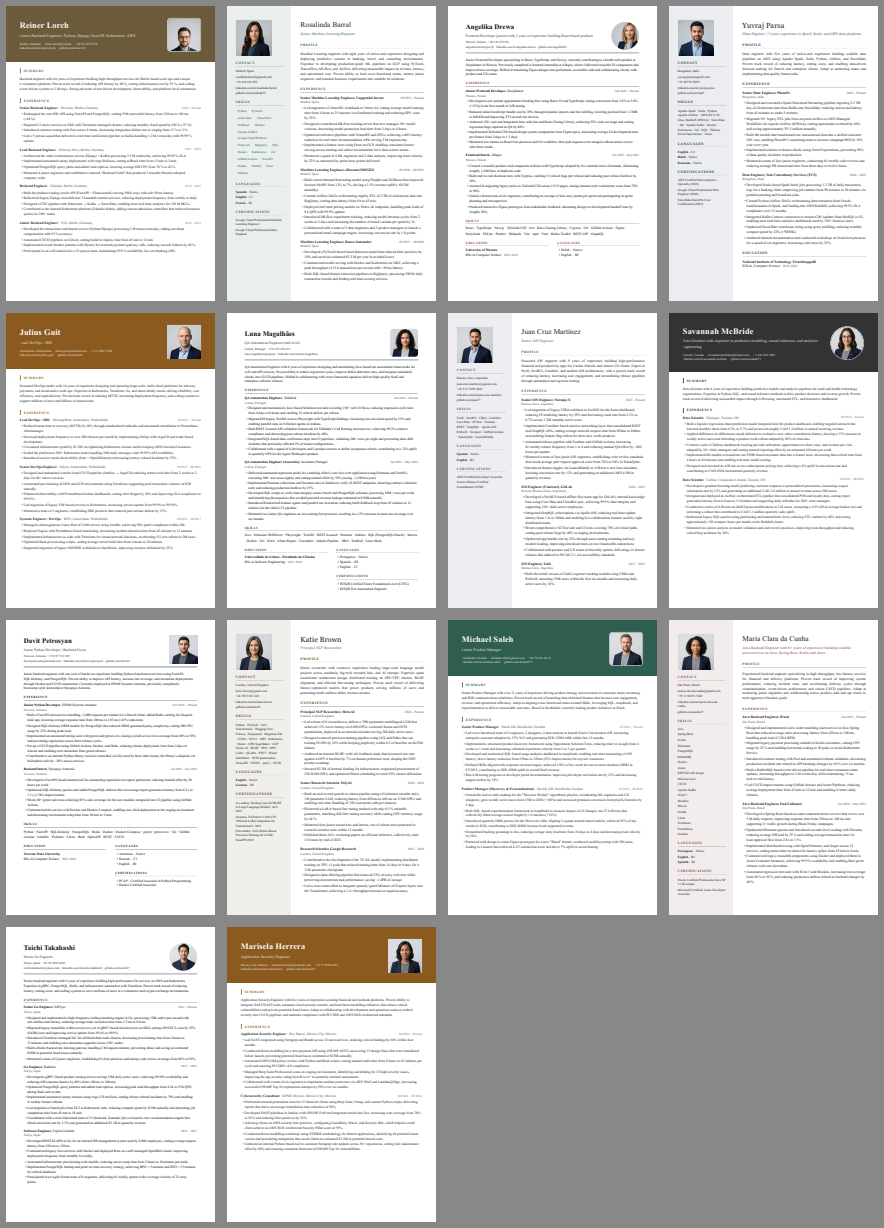

In [6]:
import pypdfium2 as pdfium
from PIL import Image


def first_page(path: Path, scale: float = 0.35) -> Image.Image:
    doc = pdfium.PdfDocument(str(path))
    img = doc[0].render(scale=scale).to_pil()
    doc.close()
    return img


thumbs = [first_page(p) for p in pdfs]
w, h = thumbs[0].size
cols = 4
rows = -(-len(thumbs) // cols)
sheet = Image.new("RGB", (cols * (w + 12), rows * (h + 12)), "#888")
for i, t in enumerate(thumbs):
    sheet.paste(t, ((i % cols) * (w + 12) + 6, (i // cols) * (h + 12) + 6))
display(sheet)

## 4. Индекс и поиск

### 4.1 Эмбеддинги

Текст → вектор из 384 чисел, модель `BAAI/bge-small-en-v1.5` через [fastembed](https://github.com/qdrant/fastembed)
(ONNX Runtime, без PyTorch, ~130 МБ, офлайн после первой загрузки, без ключа). Похожий смысл → близкие векторы, даже без общих
слов. Близость это косинус угла: 1.0 одно направление. Ниже матрица на четырёх фразах: ML-пара 0.75, остальное заметно ниже.
У bge-small высокий базовый уровень (~0.4–0.5 для любых двух английских текстов), поэтому важна разница, а не абсолют.

In [7]:
import numpy as np
from cv_screener.index.embeddings import FastEmbedder

phrases = [
    "trains deep learning models with PyTorch and deploys them to production",
    "machine learning engineer, neural networks, model serving",
    "automates regression tests with Selenium and Playwright",
    "builds React interfaces with TypeScript",
]
emb = FastEmbedder()
V = np.array(emb.embed(phrases))
print("shape:", V.shape, "→ 4 фразы × 384 числа\n")
cos = V @ V.T / (np.linalg.norm(V, axis=1)[:, None] * np.linalg.norm(V, axis=1)[None, :])
table([{"": phrases[i][:45], **{str(j): f"{cos[i, j]:.2f}" for j in range(len(phrases))}} for i in range(len(phrases))])

shape: (4, 384) → 4 фразы × 384 числа



,0,1,2,3
trains deep learning models with PyTorch and,1.00,0.75,0.57,0.47
"machine learning engineer, neural networks, m",0.75,1.00,0.61,0.47
automates regression tests with Selenium and,0.57,0.61,1.00,0.57
builds React interfaces with TypeScript,0.47,0.47,0.57,1.00


### 4.2 Документ в индексе

[ChromaDB](https://www.trychroma.com): векторная база внутри процесса, данные в `data/chroma/`, без сервера.
Метаданные только скаляры, поэтому языки и навыки лежат булевыми флагами: `lang_spanish: true`, `skill_python: true`.
`skill_variants` делает из «Python 3.11» ключи `skill_python_3_11` и `skill_python`, из «Apache Airflow» ещё и `skill_airflow`,
чтобы фильтр находил навык при любом написании.

```mermaid
flowchart TD
    C[Candidate] --> ST["search_text()<br/>имя, заголовок, саммари, навыки,<br/>языки, опыт с буллетами, образование"]
    ST --> E[bge-small] --> VEC[вектор 384 чисел]
    C --> META["скаляры: seniority, role_family,<br/>country, years_experience"]
    C --> FL["флаги: lang_*, skill_*"]
    C --> JS["json: полный профиль для get(id)"]
    VEC & META & FL & JS --> D[(документ Chroma)]
```

In [8]:
from cv_screener.index.store import CandidateIndex, Filters

idx = CandidateIndex()
print("indexed:", idx.rebuild(cands), "candidates")


def show(hits):
    table([{"score": "" if h.score is None else f"{h.score:.3f}", "name": h.name, "headline": h.headline[:45],
            "level": h.seniority, "role": h.role_family, "country": h.country, "yrs": h.years_experience,
            "languages": h.languages} for h in hits] or [{"result": "no candidates match"}])

indexed: 14 candidates


In [9]:
from cv_screener.index.store import metadata_for

meta = metadata_for(cands[0])
scalars = {k: v for k, v in meta.items() if not k.startswith(("lang_", "skill_")) and k != "json"}
flags = sorted(k for k in meta if k.startswith(("lang_", "skill_")))
print(json.dumps(scalars, indent=2, ensure_ascii=False))
print(f"\n{len(flags)} флагов, например: {', '.join(flags[:12])} …")

{
  "id": "p01-reiner-lorch",
  "name": "Reiner Lorch",
  "headline": "Senior Backend Engineer | Python, Django, FastAPI, Kubernetes, AWS",
  "seniority": "senior",
  "role_family": "backend",
  "country": "germany",
  "country_display": "Germany",
  "city": "Berlin",
  "years_experience": 10,
  "languages": "German (Native), English (C1)",
  "skills": "Python 3.11, Django 4.2, FastAPI, PostgreSQL 15, Apache Kafka 3.6, Docker, Kubernetes (EKS, GKE), AWS (EC2, RDS, S3, Lambda, CloudWatch), Redis 7, Elasticsearch 8, GraphQL (Strawberry), Terraform, Prometheus & Grafana, GitLab CI/CD, Microservices architecture, Event‑driven design, Domain‑driven design, OpenTelemetry"
}

46 флагов, например: lang_english, lang_german, skill_apache, skill_apache_kafka, skill_apache_kafka_3_6, skill_architecture, skill_aws, skill_aws_ec2_rds_s3_lambda_cloudwatch, skill_cloudwatch, skill_design, skill_django, skill_django_4_2 …


### 4.3 Поиск

`search(query, filters, k)`: `Filters.to_where()` собирает условие Chroma (`$in`, `$gte`, `$and`); без текста запроса это
`collection.get(where)`, с текстом `collection.query(vector, where, k)`, где фильтр сужает, а косинус ранжирует.
`get(id)` читает профиль из поля `json`, `find_by_name` сравнивает имена через `difflib`. Эти три функции дёргает агент,
их же можно отдать как MCP-тулы.

```mermaid
flowchart LR
    F[filters] --> W["to_where()"]
    Q[query] --> V[вектор]
    W & V --> S{query?}
    S -->|нет| G["get(where)"]
    S -->|да| R["query(vector, where, k)"]
    G & R --> H[Hit...]
```

**По полям.** `lang_spanish`. Michael Saleh с A2 тоже здесь: флаг не знает уровня, это решит агент.

In [10]:
show(idx.search(None, Filters(languages=["Spanish"]), k=10))

score,name,headline,level,role,country,yrs,languages
,Michael Saleh,Senior Product Manager,senior,product,Sweden,11,"Swedish (Native), English (C2), Spanish (A2)"
,Juan Cruz Martinez,Senior iOS Engineer,senior,mobile,Argentina,9,"Spanish (Native), English (B2)"
,Rosalinda Barral,Senior Machine Learning Engineer,senior,ml,Spain,8,"Spanish (Native), English (C1), French (B1)"
,Maria Clara da Cunha,Java Backend Engineer with 6+ years of experi,middle,backend,Brazil,6,"Portuguese (Native), English (B2), Spanish (B1)"
,Marisela Herrera,Application Security Engineer,middle,security,Mexico,5,"Spanish (Native), English (C1)"
,Luna Magalhães,QA Automation Engineer (mid-level),middle,qa,Portugal,4,"Portuguese (Native), Spanish (B2), English (C1)"


**По полям.** `skill_python`, включая Reiner с записью «Python 3.11».

In [11]:
show(idx.search(None, Filters(skills=["Python"]), k=14))

score,name,headline,level,role,country,yrs,languages
,Katie Brown,Principal NLP Researcher,principal,ml,United Kingdom,15,"English (Native), German (B2)"
,Julius Guit,Lead DevOps / SRE,lead,devops,Netherlands,14,"Dutch (Native), English (C2)"
,Reiner Lorch,"Senior Backend Engineer | Python, Django, Fas",senior,backend,Germany,10,"German (Native), English (C1)"
,Rosalinda Barral,Senior Machine Learning Engineer,senior,ml,Spain,8,"Spanish (Native), English (C1), French (B1)"
,Marisela Herrera,Application Security Engineer,middle,security,Mexico,5,"Spanish (Native), English (C1)"
,Yuvraj Parsa,"Data Engineer | 5 years experience in Spark,",middle,data,India,5,"English (C2), Hindi (Native), Kannada (Native)"
,Savannah McBride,Data Scientist with expertise in predictive m,middle,data-science,Canada,4,"English (Native), French (C1), Mandarin (B1)"
,Davit Petrosyan,Junior Python Developer | Backend Focus,junior,backend,Armenia,1,"Armenian (Native), Russian (C1), English (B1)"


**По смыслу.** Слов «senior ML» в резюме нет, но Rosalinda и Katie ближе всех, бэкендеры с Python идут с отрывом.

In [12]:
show(idx.search("senior machine learning engineer, deep learning, model deployment", k=5))

score,name,headline,level,role,country,yrs,languages
0.794,Rosalinda Barral,Senior Machine Learning Engineer,senior,ml,Spain,8,"Spanish (Native), English (C1), French (B1)"
0.726,Katie Brown,Principal NLP Researcher,principal,ml,United Kingdom,15,"English (Native), German (B2)"
0.674,Reiner Lorch,"Senior Backend Engineer | Python, Django, Fas",senior,backend,Germany,10,"German (Native), English (C1)"
0.665,Yuvraj Parsa,"Data Engineer | 5 years experience in Spark,",middle,data,India,5,"English (C2), Hindi (Native), Kannada (Native)"
0.647,Taichi Takahashi,Senior Go Engineer,senior,backend,Japan,9,"Japanese (Native), English (B2)"


**Гибрид.** Тот же запрос, фильтр по уровню отсекает middle и junior до ранжирования.

In [13]:
show(idx.search("machine learning research and production ML systems",
                Filters(seniority=["senior", "lead", "principal"]), k=5))

score,name,headline,level,role,country,yrs,languages
0.715,Rosalinda Barral,Senior Machine Learning Engineer,senior,ml,Spain,8,"Spanish (Native), English (C1), French (B1)"
0.666,Katie Brown,Principal NLP Researcher,principal,ml,United Kingdom,15,"English (Native), German (B2)"
0.595,Reiner Lorch,"Senior Backend Engineer | Python, Django, Fas",senior,backend,Germany,10,"German (Native), English (C1)"
0.576,Michael Saleh,Senior Product Manager,senior,product,Sweden,11,"Swedish (Native), English (C2), Spanish (A2)"
0.570,Julius Guit,Lead DevOps / SRE,lead,devops,Netherlands,14,"Dutch (Native), English (C2)"


**Пусто.** Иврита нет, индекс возвращает пустой список. И нечёткий поиск по имени.

In [14]:
show(idx.search(None, Filters(languages=["Hebrew"])))
print(idx.find_by_name("Katie"))

result
no candidates match


[Hit(id='p10-katie-brown', name='Katie Brown', headline='Principal NLP Researcher', seniority='principal', role_family='ml', country='United Kingdom', years_experience=15, languages='English (Native), German (B2)', skills='Python, PyTorch, JAX, Transformers, Hugging Face, Fairseq, Deepspeed, Megatron-LM, CUDA, NCCL, MPI, Kubernetes, Slurm, AWS SageMaker, GCP Vertex AI, RLHF, PPO, DPO, LoRA, QLoRA, PEFT, Model distillation, INT8 quantization, TensorRT, ONNX, spaCy, NLTK', score=1.0)]


### 4.4 Тесты без сети

`CandidateIndex` принимает эмбеддер в конструкторе. В тестах это `HashEmbedder`: слово → одна из 64 позиций вектора,
общие слова дают близкие векторы, детерминировано и мгновенно. Проверяется сантехника: флаги, фильтры, ранжирование, `get`,
перестройка. Продакшн берёт bge по умолчанию. Тот же приём будет в агенте с фейковой LLM.

## 5. Агент (нужен API-ключ)

Цикл tool use на `openai` SDK поверх OpenRouter, без фреймворка: `agent/loop.py` и `agent/tools.py`. Модель получает
системный промпт и три тула в формате function calling: `search_candidates` (те же `query` и фильтры, что у `search`),
`get_candidate`, `find_by_name`. Датасет в контекст не попадает, только то, что вернули тулы.

```mermaid
sequenceDiagram
    participant U as Пользователь
    participant A as Agent.ask
    participant M as Модель
    participant T as tools.dispatch → CandidateIndex
    U->>A: вопрос
    loop до max_steps
        A->>M: messages + TOOLS
        alt tool_calls
            M-->>A: search_candidates(languages=[Spanish], k=10)
            A->>T: dispatch
            T-->>A: JSON с id, именами, score
            A->>A: append role=tool
        else текст
            M-->>A: финальный ответ
        end
    end
    A->>A: имена в ответе ⊆ имена из тулов?
    A-->>U: Answer(text, trace, grounded)
```

Заземление в двух местах. Промпт: называть только тех, кто пришёл из тулов, при пустом результате говорить, что никого нет,
слабые совпадения (score ниже ~0.6) не натягивать. Код: после ответа сверяются имена из текста с id, которые вернули тулы;
лишние попадают в `ungrounded_names`, и `cv chat` печатает предупреждение. Эвалы в разделе 6 проверяют это на реальной модели.

In [15]:
from cv_screener.agent.loop import Agent
from cv_screener.llm import LLM

agent = Agent(LLM(), idx)


def ask(q: str) -> None:
    print(f"▶ {q}")
    a = agent.ask(q, on_tool=lambda t: print(f"   → {t.name}({t.args}) → {t.count}"))
    print(a.text)
    print(f"   [grounded={a.grounded}{', ungrounded: ' + ', '.join(a.ungrounded_names) if a.ungrounded_names else ''}; model={a.model}]\n")

Четыре вопроса из задания и один без ответа в датасете.

In [16]:
ask("Who has experience with Python?")

▶ Who has experience with Python?


   → search_candidates({'skills': ['Python'], 'k': 20}) → 8


- Katie Brown – Principal NLP Researcher (Python listed among her skills)  
- Julius Guit – Lead DevOps / SRE (Python listed among his skills)  
- Reiner Lorch – Senior Backend Engineer (Python 3.11, Django, FastAPI)  
- Rosalinda Barral – Senior Machine Learning Engineer (Python listed among her skills)  
- Marisela Herrera – Application Security Engineer (Python listed among her skills)  
- Yuvraj Parsa – Data Engineer (Python listed among his skills)  
- Savannah McBride – Data Scientist (Python listed among her skills)  
- Davit Petrosyan – Junior Python Developer (Python listed among his skills)
   [grounded=True; model=nvidia/nemotron-3-super-120b-a12b:free]



In [17]:
ask("Which candidates speak Spanish?")

▶ Which candidates speak Spanish?


   → search_candidates({'k': 20, 'languages': ['Spanish']}) → 6


- **Michael Saleh** – Senior Product Manager (Sweden) – Languages: Swedish (Native), English (C2), **Spanish (A2)**  
- **Juan Cruz Martinez** – Senior iOS Engineer (Argentina) – Languages: **Spanish (Native)**, English (B2)  
- **Rosalinda Barral** – Senior Machine Learning Engineer (Spain) – Languages: **Spanish (Native)**, English (C1), French (B1)  
- **Maria Clara da Cunha** – Java Backend Engineer (Brazil) – Languages: Portuguese (Native), English (B2), **Spanish (B1)**  
- **Marisela Herrera** – Application Security Engineer (Mexico) – Languages: **Spanish (Native)**, English (C1)  
- **Luna Magalhães** – QA Automation Engineer (Portugal) – Languages: Portuguese (Native), **Spanish (B2)**, English (C1)  

These candidates all list Spanish in their language profile, confirming they speak Spanish.
   [grounded=True; model=nvidia/nemotron-3-super-120b-a12b:free]



In [18]:
ask("Who would be the best fit for a senior ML role?")

▶ Who would be the best fit for a senior ML role?


   → search_candidates({'role_family': ['ml', 'data-science'], 'seniority': ['senior', 'lead', 'principal'], 'k': 10, 'query': 'senior ML role'}) → 2


- **Rosalinda Barral** – Senior Machine Learning Engineer (senior, 8 years experience). She lists Python, PyTorch, scikit‑learn, TensorFlow, XGBoost, MLflow, Airflow, GCP/Vertex AI, BigQuery, SQL, Docker, Kubernetes, FastAPI, Pandas, NumPy, Feast, Tableau, and speaks Spanish (native), English (C1), French (B1). Score 0.712.  
- **Katie Brown** – Principal NLP Researcher (principal, 15 years experience). She lists Python, PyTorch, JAX, Transformers, Hugging Face, Fairseq, Deepspeed, Megatron‑LM, CUDA, NCCL, MPI, Kubernetes, AWS SageMaker, GCP Vertex AI, RLHF, PPO, DPO, LoRA, QLoRA, PEFT, model distillation, INT8 quantization, TensorRT, ONNX, spaCy, NLTK, and speaks English (native), German (B2). Score 0.646.  

Rosalinda Barral has the higher relevance score and a senior‑level ML engineering background, making her the best fit for a senior ML role.
   [grounded=True; model=nvidia/nemotron-3-super-120b-a12b:free]



In [19]:
ask("Summarize the profile of Davit Petrosyan")

▶ Summarize the profile of Davit Petrosyan


   → find_by_name({'name': 'Davit Petrosyan'}) → 1


   → get_candidate({'candidate_id': 'p09-davit-petrosyan'}) → 1


**Davit Petrosyan – Junior Python Developer (Backend Focus)**  
- **Seniority / Experience:** Junior, 1 year of professional experience  
- **Location:** Yerevan, Armenia  
- **Languages:** Armenian (Native), Russian (C1), English (B1)  
- **Core Skills:** Python, FastAPI, SQLAlchemy, PostgreSQL, Redis, Docker, Docker‑Compose, pytest, GitHub Actions, Alembic, Pydantic, Linux, Bash, OpenAPI, REST, CI/CD  
- **Current Role:** Junior Python Developer at EPAM Systems Armenia (since Oct 2025)  
  - Built a FastAPI microservice handling ~2k rpm; added Redis caching → response time ↓ 41% (280 ms → 165 ms)  
  - Designed SQLAlchemy ORM models → DB CPU usage ↓ 22% at peak load  
  - Raised test coverage from 68% to 92% with pytest/pytest‑cov  
  - Set up GitHub Actions CI/CD pipeline (Docker, Helm) → deployment time ↓ from 2 days to 4 hours, enabling zero‑downtime blue‑green releases  
  - Contributed to an internal Python library used by three teams → boilerplate code ↓ ~30%  
- **Previous Rol

In [20]:
ask("Who speaks Hebrew?")

▶ Who speaks Hebrew?


   → search_candidates({'k': 20, 'languages': ['Hebrew']}) → 0


No candidates in the dataset list Hebrew as a spoken language.
   [grounded=True; model=nvidia/nemotron-3-super-120b-a12b:free]



## 6. Эвалы (нужен API-ключ)

Эвалы проверяют поведение агента на реальной модели: `evals/cases.json`
описывает вопрос и ожидание, `evals/run.py` прогоняет каждый через `Agent.ask` и печатает pass/fail.

Ожидание в трёх формах: `must_include` (эти кандидаты обязаны быть названы), `must_exclude` (эти не должны), `expect_no_match`
(ни одного имени из датасета в ответе). Плюс два общих правила для всех кейсов: хотя бы один вызов тула и заземление,
то есть каждое имя в ответе пришло из тулов. Совпадение по полному имени или фамилии, они в датасете уникальны.
Результат прогона переносится в `NOTES.md` как есть, включая падения.

In [21]:
import sys
sys.path.insert(0, "evals")
from run import run, CASES

cases = json.loads(CASES.read_text())
table([{"id": c["id"], "question": c["question"],
        "expects": "no match" if c.get("expect_no_match") else f"+{len(c.get('must_include', []))} / −{len(c.get('must_exclude', []))}",
        "note": c["note"]} for c in cases])

id,question,expects,note
python-skill,Who has experience with Python?,+8 / −3,"field filter; Reiner lists 'Python 3.11', must still be found"
spanish-language,Which candidates speak Spanish?,+4 / −3,natives and B2 must appear; A2/B1 speakers are allowed either way
senior-ml-fit,Who would be the best fit for a senior ML role?,+1 / −3,semantic + seniority; Katie Brown (principal) is acceptable too
summarize-katie,Summarize the profile of Katie Brown,+1 / −2,find_by_name then get_candidate; nobody else should be mentioned
portuguese-language,Who speaks Portuguese?,+2 / −2,language filter must not confuse Portuguese with Spanish speakers
years-filter,Which candidates have at least 12 years of experience?,+2 / −3,numeric filter; Reiner has exactly 10 and must be excluded
no-match-hebrew,Who speaks Hebrew?,no match,"empty filter result → must say nobody, name no one"
no-match-cobol,Does anyone have COBOL experience?,no match,"skill nobody has; semantic search will still return nearest neighbours, agent must not stretch"
no-match-unknown-person,Summarize the profile of John Smith,no match,name not in dataset; find_by_name returns nothing


In [22]:
results = run(cases, agent, idx.names())
print(f"\n{sum(r.passed for r in results)}/{len(results)} passed")

[PASS] python-skill                 tools=1  26.8s  nvidia/nemotron-3-ultra-550b-a55b:free


[PASS] spanish-language             tools=1  19.1s  nvidia/nemotron-3-super-120b-a12b:free


[PASS] senior-ml-fit                tools=1   9.4s  nvidia/nemotron-3-super-120b-a12b:free


[PASS] summarize-katie              tools=2  13.1s  nvidia/nemotron-3-super-120b-a12b:free


[PASS] portuguese-language          tools=1   6.3s  nvidia/nemotron-3-super-120b-a12b:free


[PASS] years-filter                 tools=1   4.6s  nvidia/nemotron-3-super-120b-a12b:free


[PASS] no-match-hebrew              tools=1   4.3s  nvidia/nemotron-3-super-120b-a12b:free


[PASS] no-match-cobol               tools=1   3.6s  nvidia/nemotron-3-super-120b-a12b:free


[PASS] no-match-unknown-person      tools=1   4.0s  nvidia/nemotron-3-super-120b-a12b:free

9/9 passed
